# 03 — Real data: NGC 5102 MUSE galactic center

NGC 5102 is a lenticular galaxy at 3.66 Mpc observed with VLT/MUSE (0.2 arcsec/spaxel).
This notebook fits the central spaxel's spectrum to recover the line-of-sight
velocity distribution (LOSVD) from the Ca II triplet region.

The spectrum (`bin0105sp.spec`) is the single pixel/spaxel centered on the galactic
center, extracted using the same binning scheme as the SCO framework (not Voronoi
binning), and is bundled in `examples/data/muse/`.

**Key aspects of real data:**
- Raw flux (counts, not normalized) — `fit_continuum=True` handles this by co-fitting a
  penalized-B-spline continuum directly into the same optimization as the LOSVD and
  template weights (see `kinextract.joint`)
- Galaxy redshift: `zgal = 0.001556` -- NCG 5012's redshift from NED
- MUSE's per-pixel flux errors have some scaling issues, so we override them with a
  uniform S/N-based estimate (`gal_errors=flux/50`) rather than using `use_spectrum_errors=True` 
  directly.
- Stellar templates: real stellar spectra from the MUSE Library of Stellar Spectra
  (`examples/data/muse/Tlist`).

Note: continuum-cofit fits like this one don't yet support
`LOSVDErrorEstimator.laplace_covariance`/`bias_correction` (see Section 6) -- only
`residual_bootstrap`. If you need Laplace or bias-corrected error bars, pre-normalize
the spectrum once (e.g. via the standalone
`kinextract.continuum.asymmetric_least_squares_continuum` utility -- see
`examples/notebooks/06_prenormalized_workflow.ipynb`) and fit with
`fit_continuum=False` instead.

In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

from kinextract import FitConfig, run_spectral_fit, set_verbose

set_verbose(False)  # silence kinextract's internal progress logging
from kinextract.fitting import fit_losvd_gauss_hermite


# Path to bundled example data (adjust if running from a different location)
DATA_DIR = Path('..') / 'data'
MUSE_DIR = DATA_DIR / 'muse'

# ── To use a different spectrum, change this line ────────────────────────────
SPEC_FILE = MUSE_DIR / 'bin0105sp.spec'

## 1. Load and inspect the spectrum

In [2]:
# ── Wavelength grid ───────────────────────────────────────────────────────────
# The .spec file contains integer pixel indices (1–3681); kinextract reconstructs
# wavelengths as: wave = wavemin_full + (pix - 1) * step
WAVEMIN_FULL = 4750.0    # Å, pixel 1
STEP         = 1.25      # Å / pixel
N_PIX        = 3681
wavelength   = WAVEMIN_FULL + np.arange(N_PIX) * STEP   # observed-frame grid

data = np.loadtxt(SPEC_FILE)
pix, flux, ferr_real = data[:, 0].astype(int), data[:, 1], data[:, 2]

# MUSE's flux errors are underestimated, so we can use a simple S/N estimate to set the errors instead
snr = 25.0
ferr = flux / snr

print(f"Spectrum pixels: {len(flux)}")
print(f"Flux range:  {flux.min():.0f} – {flux.max():.0f}  counts")
print(f"Error range: {ferr.min():.0f} – {ferr.max():.0f}  counts")
print(f"Median S/N per pixel: {np.median(flux / ferr):.1f}")

Spectrum pixels: 3681
Flux range:  25340 – 80715  counts
Error range: 1014 – 3229  counts
Median S/N per pixel: 25.0


## 2. Quick-look: raw spectrum over the Ca II fitting region

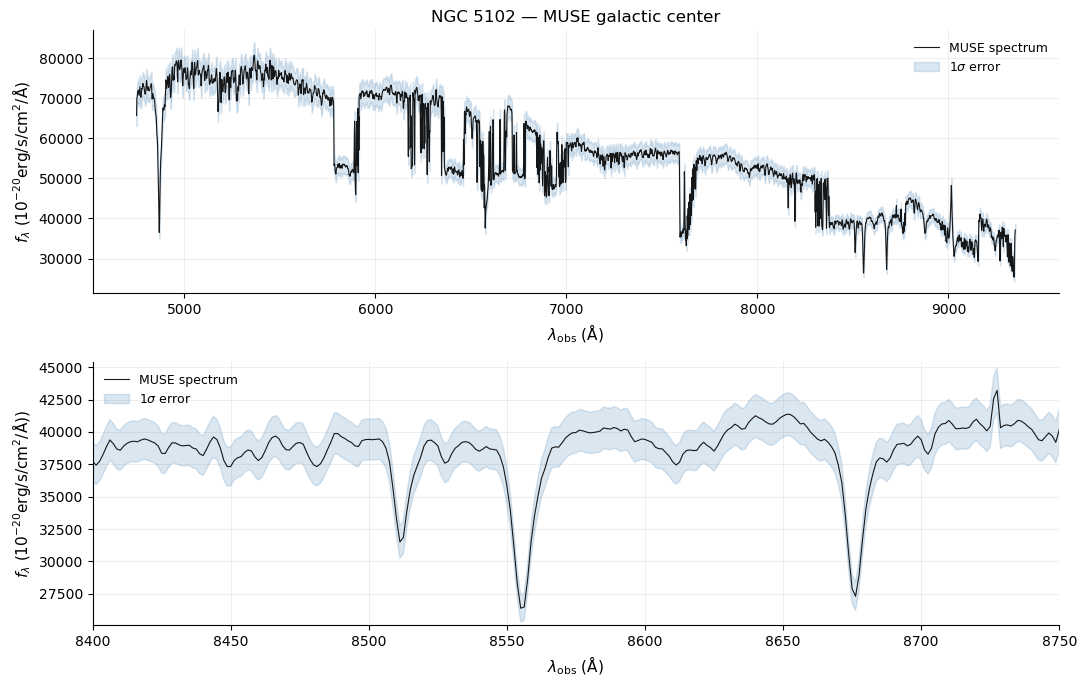

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7))
ax[0].plot(wavelength, flux, lw=0.8, color='black', alpha=0.9, label='MUSE spectrum')
ax[0].fill_between(wavelength, flux - ferr, flux + ferr, alpha=0.20, color='steelblue', label=r'$1\sigma$ error')
ax[0].set_xlabel(r'$\lambda_{\mathrm{obs}}$ ($\mathrm{\AA}$)')
ax[0].set_ylabel(r'$f_\lambda$ $(\mathrm{10^{-20} erg/s/cm^2/\AA})$')
ax[0].set_title('NGC 5102 — MUSE galactic center')
ax[1].set_xlabel(r'$\lambda_{\mathrm{obs}}$ ($\mathrm{\AA}$)')
ax[1].set_ylabel(r'$f_\lambda$ $(\mathrm{10^{-20} erg/s/cm^2/\AA})$)')

ax[1].plot(wavelength, flux, lw=0.8, color='black', alpha=0.9, label='MUSE spectrum')
ax[1].fill_between(wavelength, flux - ferr, flux + ferr, alpha=0.20, color='steelblue', label=r'$1\sigma$ error')
ax[1].set_xlim(8400, 8750)
ax[1].set_ylim(0.95 * flux[(wavelength > 8400)&(wavelength < 8750)].min(), 
               1.05 * flux[(wavelength > 8400)&(wavelength < 8750)].max())
ax[0].legend(fontsize=9, framealpha=1.0, facecolor='white').set_zorder(20)
ax[1].legend(fontsize=9, framealpha=1.0, facecolor='white').set_zorder(20)
plt.tight_layout()
plt.show()

## 3. FitConfig and run

In [4]:

cfg = FitConfig(
    template_list_file    = str(MUSE_DIR / 'Tlist'),
    template_dir          = str(MUSE_DIR),
    # outdir="./my_output_dir", write_outputs=True,  # uncomment to save .fit/.temp/.ascii/.rms output files
    wavemin_full          = WAVEMIN_FULL,  # Å, minimum wavelength of full spectrum (pixel 1)
    step                  = STEP,          # Å / pixel
    wavefitmin            = 8400.0,        # Å  (rest-frame; kinextract applies zgal)
    wavefitmax            = 8750.0,        # Å
    zgal                  = 0.001556,      # redshift of NGC 5102 (from NED)
    n_losvd_bins          = 29,            # number of LOSVD bins (for the non-parametric LOSVD)
    losvd_vmin            = -270.0,        # km/s
    losvd_vmax            = +270.0,        # km/s
    fit_continuum         = True,
    use_spectrum_errors   = False,         # gal_errors= below takes priority; this is ignored
    xlam_auto              = True,
    sigl                   = 50.0,         # km/s, initial guess for LOSVD sigma (used to set the initial LOSVD)
    clean                  = True,
    map_maxiter           = 5000,
    print_every           = 10000,
)

# Run the fit with the S/N-based error guess from above

fit = run_spectral_fit(cfg, gal_file=str(SPEC_FILE), gal_errors=ferr)
st  = fit['state']
out = fit['outputs']
b   = out['b']
gp  = out['gp']
print(f"χ²_red = {out['chi2_red']:.3f}")
print(f"xlam used = {st.xlam}")
print(f"success     : {fit['result'].success}")
if not fit['result'].success:
    print(f"  WARNING: L-BFGS-B did not converge ({fit['result'].message}) -- treat "
          "V/sigma/h3/h4 as unreliable; consider raising map_maxiter or loosening map_ftol.")

# NOTE: The MUSE data is very high S/N, so the fit is basically perfect to the spectrum, causing chi^2
# to be very small.

χ²_red = 0.023
xlam used = 352.26946514731014
success     : True


## 4. Gauss-Hermite moments

In [5]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)
print(f"V      = {gh['vherm']:+.1f} km/s")
print(f"sigma  = {gh['sherm']:.1f} km/s")
print(f"h3     = {gh['h3']:+.4f}")
print(f"h4     = {gh['h4']:+.4f}")

V      = +30.0 km/s
sigma  = 52.2 km/s
h3     = -0.0207
h4     = +0.0112


## 5. Fit Results

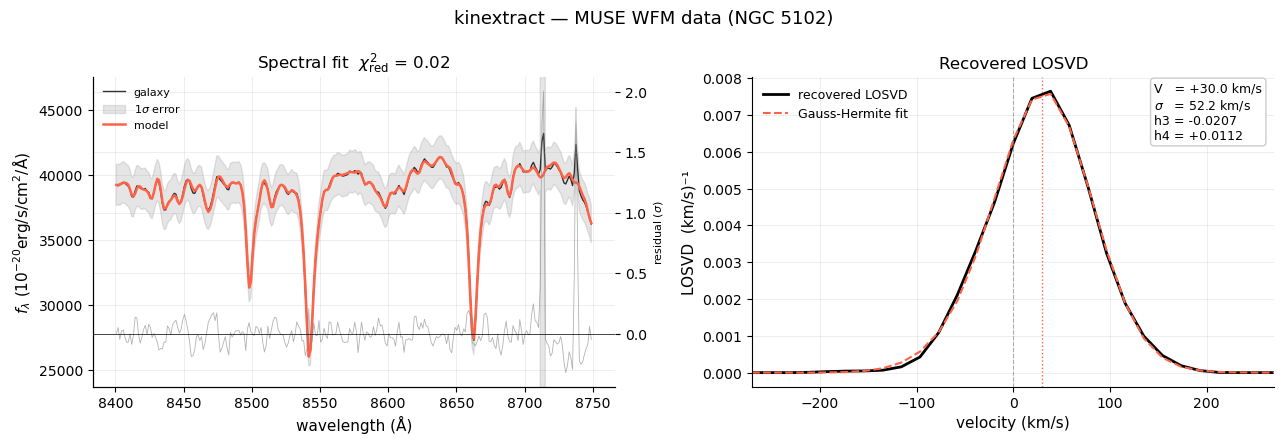

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('kinextract — MUSE WFM data (NGC 5102)', fontsize=13)

# ── Panel 1: spectral fit ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='black', label='galaxy', alpha=0.8)
ax.fill_between(st.x, st.g - st.gerr, st.g + st.gerr, alpha=0.20, color='gray', label=r'$1\sigma$ error')
ax.plot(st.x, gp, lw=1.8, color='tomato', label='model', zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax.set_ylim(0.9*st.g.min(), 1.1*st.g.max())
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.6)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel('wavelength (Å)')
ax.set_ylabel(r'$f_\lambda$ ($10^{-20} \mathrm{erg/s/cm^2/\AA}$)')
ax.set_title(r'Spectral fit  $\chi^2_{\rm red}$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)

# ── Panel 2: LOSVD ────────────────────────────────────────────────────────────
ax = axes[1]
b_norm = b / trapezoid(b, st.xl)
ax.plot(st.xl, b_norm, lw=2.0, color='black', label='recovered LOSVD')
ax.plot(st.xl, gh['model']/trapezoid(gh['model'], st.xl), lw=1.5, color='tomato', ls='--', label='Gauss-Hermite fit')
ax.axvline(gh['vherm'], lw=1.0, color='tomato', ls=':')
ax.axvline(0,           lw=0.8, color='grey',   ls='--', alpha=0.6)
ax.text(0.77, 0.79,
        f"V   = {gh['vherm']:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {gh['sherm']:.1f} km/s\n"
        f"h3 = {gh['h3']:+.4f}\n"
        f"h4 = {gh['h4']:+.4f}",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))
ax.set_xlabel('velocity (km/s)')
ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title('Recovered LOSVD')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()

## 6. Error estimation

Uncertainty on the LOSVD is estimated via **residual bootstrap**: resample fit residuals into synthetic spectra and refit each through the same pipeline (here, `kinextract.joint`, at the main fit's own converged xlam/sigl0/v_center) -> an independent, frequentist estimate of the LOSVD's scatter. Slower than a closed-form approximation since each of `N_BOOT` replicates is a full refit, but the only supported method for continuum-cofit fits: `laplace_covariance`/`bias_correction` don't yet understand the joint method's parameter layout and raise `NotImplementedError`.

In [7]:
from kinextract import LOSVDErrorEstimator

N_BOOT = 50   # This takes about 2 minutes to complete;increase to a 200+ for publication

est     = LOSVDErrorEstimator(fit, cfg)
boot    = est.residual_bootstrap(n_bootstrap=N_BOOT, n_jobs=2)
summary = est.summarize(bootstrap_result=boot)

gh_map = summary['gh_map']
gh_err = summary.get('gh_err_recommended', {})
print("Bootstrap uncertainties:")
for label, mkey, ekey in [('V', 'vherm', 'gh_vherm'), ('σ', 'sherm', 'gh_sherm'),
                           ('h3', 'h3', 'gh_h3'), ('h4', 'h4', 'gh_h4')]:
    val = gh_map.get(mkey)
    err = gh_err.get(ekey)
    if val is not None:
        err_str = f' ± {err:.2f}' if err is not None else ''
        unit = ' km/s' if label in ('V', 'σ') else ''
        print(f'  {label:5s} = {val:+.2f}{unit}{err_str}')

[LOSVDErrors] Starting residual bootstrap (n=50, block=1, jobs=2)...
[LOSVDErrors] Using 2 worker threads
[LOSVDErrors] Bootstrap 5/50 (6s elapsed)
[LOSVDErrors] Bootstrap 10/50 (10s elapsed)
[LOSVDErrors] Bootstrap 15/50 (14s elapsed)
[LOSVDErrors] Bootstrap 20/50 (19s elapsed)
[LOSVDErrors] Bootstrap 25/50 (24s elapsed)
[LOSVDErrors] Bootstrap 30/50 (28s elapsed)
[LOSVDErrors] Bootstrap 35/50 (33s elapsed)
[LOSVDErrors] Bootstrap 40/50 (37s elapsed)
[LOSVDErrors] Bootstrap 45/50 (41s elapsed)
[LOSVDErrors] Bootstrap 50/50 (45s elapsed)
[LOSVDErrors] Bootstrap done in 44.7s. Success: 50/50

LOSVD ERROR SUMMARY
  Gauss-Hermite moments (MAP, consistent with pallmc.f):
    V    = +30.01 km/s ± 3.71
    σ    = 52.24 km/s ± 1.36
    h3   = -0.0207 ± 0.0145
    h4   = +0.0112 ± 0.0119
  LOSVD moments (for reference):
    V    = +28.65 km/s ± 3.97
    σ    = 53.42 km/s ± 3.11

  Bootstrap: 50 successful / 50 total replicates

Bootstrap uncertainties:
  V     = +30.01 km/s ± 3.71
  σ     = +5

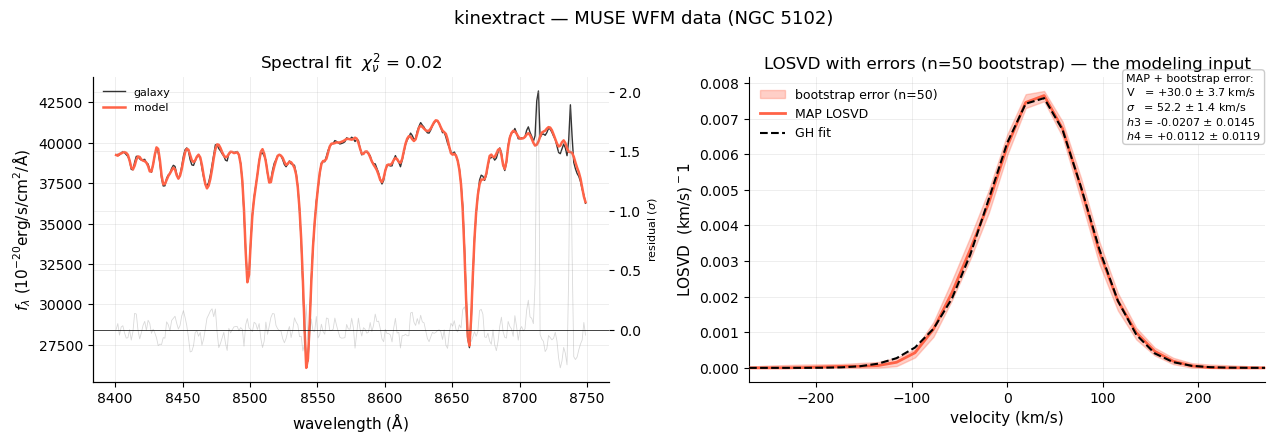

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('kinextract — MUSE WFM data (NGC 5102)', fontsize=13)

# --- spectral fit ---
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='black', label='galaxy', alpha=0.8)
ax.plot(st.x, gp, lw=1.8, color='tomato',    label='model',  zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.3)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel(r'wavelength ($\mathrm{\AA}$)')
ax.set_ylabel(r'$f_\lambda$ ($10^{-20} \mathrm{erg/s/cm^2/\AA}$)')
ax.set_title(r'Spectral fit  $\chi^2_\nu$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)


b_trap   = trapezoid(b, st.xl)
b_norm   = b / b_trap
b_lo = summary['b_lo_recommended'] / b_trap
b_hi = summary['b_hi_recommended'] / b_trap

gh_med = summary['gh_center_recommended']
gh_model_norm = gh_med['model'] / trapezoid(gh_med['model'], st.xl)

ax = axes[1]

ax.fill_between(st.xl, b_lo, b_hi, alpha=0.30, color='tomato',
                label=f'bootstrap error (n={N_BOOT})')
ax.plot(st.xl, b_norm, lw=2.0, color='tomato', zorder=5, label='MAP LOSVD')
ax.plot(st.xl, gh_model_norm, lw=1.5, ls='--', color='black', zorder=6, label='GH fit')

ax.text(0.73, 0.79,
        f"MAP + bootstrap error:\n"
        fr"V   = {gh_med['vherm']:+.1f} $\pm$ {gh_err.get('gh_vherm', float('nan')):.1f}" + " km/s\n"
        fr"$\sigma$   = {gh_med['sherm']:.1f} $\pm$ {gh_err.get('gh_sherm', float('nan')):.1f}" + " km/s\n"
        fr"$h3$ = {gh_med['h3']:+.4f} $\pm$ {gh_err.get('gh_h3', float('nan')):.4f}" + "\n"
        fr"$h4$ = {gh_med['h4']:+.4f} $\pm$ {gh_err.get('gh_h4', float('nan')):.4f}",
        transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel(r'LOSVD  (km/s)$^-1$')
ax.set_title(f'LOSVD with errors (n={N_BOOT} bootstrap) — the modeling input')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()

## 7. Built-in diagnostic plots

`kinextract.plotting` ships ready-made diagnostic plots so you don't have to
write custom matplotlib code for routine quick-looks:

- `plot_losvd(fit)` — same idea as the panels built by hand
  in Section 5, but in one line.
- `plot_continuum(fit, cfg)` — specifically for `fit_continuum=True`
  fits like this one. Shows the data, model, and co-fit continuum baseline; a
  continuum-normalized view; and residuals, with detected emission regions
  shaded and labeled. Passing `cfg` (rather than leaving it out) adds
  labels for the specific lines this fit's masking actually detected, on top
  of the curated reference-line ticks shown either way.

Note: in this case, the cleaning algorithm is picking up some spurious "emission" 
features. It doesn't meanfully affect the quality of the fit, but it will be addressed 
in a future release.

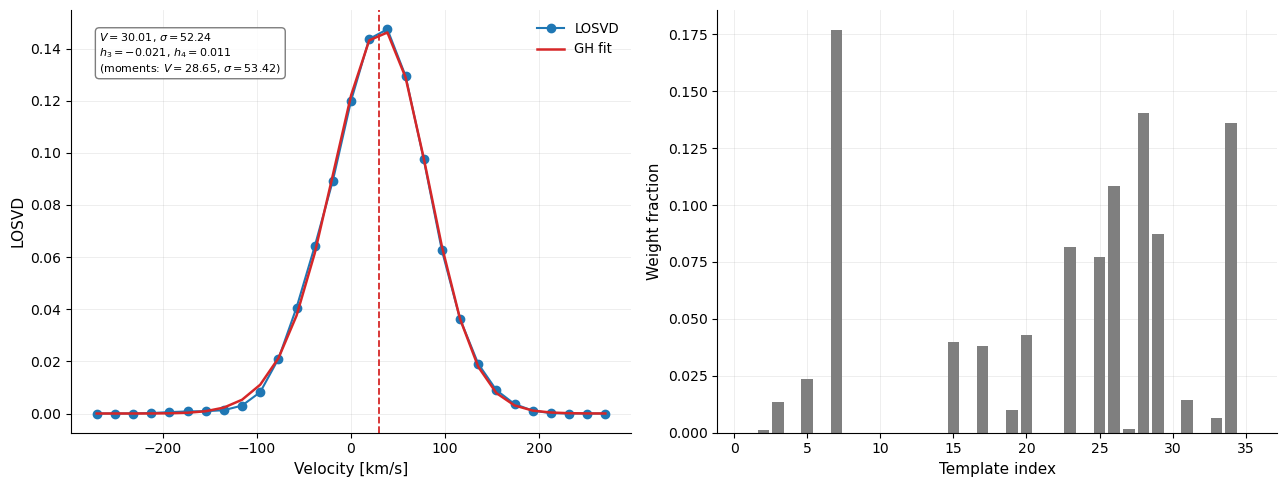

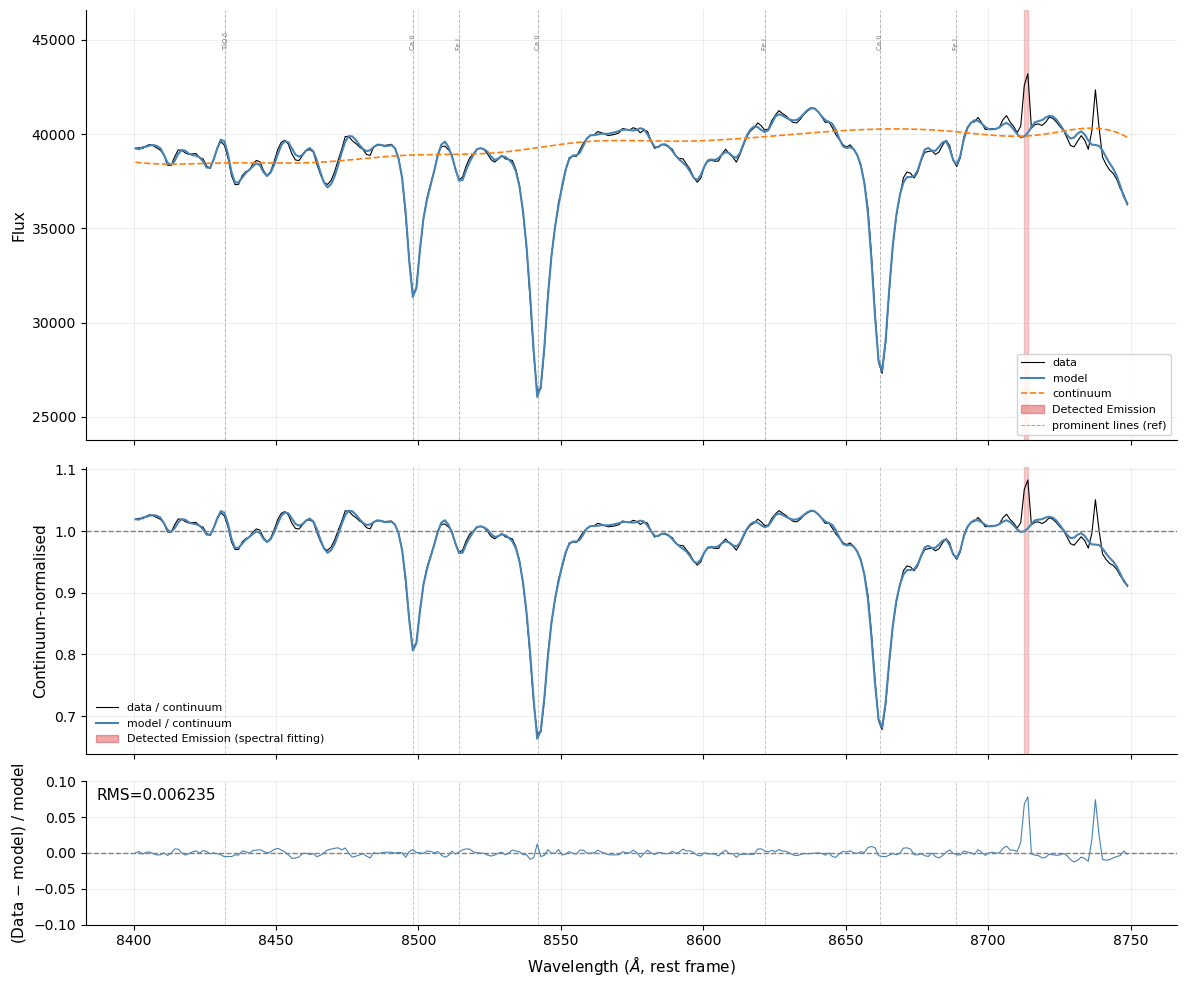

In [9]:
from kinextract.plotting import plot_fit, plot_losvd, plot_continuum

plot_losvd(fit)
plot_continuum(fit, cfg)